# Phase C — Modeling & Comparison

CRISP-DM *Modeling* + *Evaluation*. We train the course's classifiers on the leakage-safe data from
Phase B and let the metrics pick a winner, no model is assumed best in advance (No-Free-Lunch).
**This phase:** the 6 models (below), then a synthesis, model comparison, feature ablation,
scope `2000` vs `all`, threshold 20% vs 30%.

## Setup (shared by every model)

- **Data:** `data/processed/scope_2000_2018/` (primary scope from Phase B). Features: `genre`,
  `platform_family`, `publisher_tier`. Target: `Hit` (sales in the year's top 20%). 
- **Imbalance:** each model is run **twice** — no resampling, and with a 50/50 train downsample
  (Lec 5: balance classes during training).
- **Evaluation:** held-out test set, **ROC-AUC + F-measure (F1) + confusion matrix**; the bar to beat is
  the majority baseline (always-"Flop" ≈ 80% accuracy but 0 recall).

## Models

The six classifiers are **kNN, Naive Bayes, Decision Tree, Random Forest, ANN (MLP), Logistic
Regression**. Each gets its own section. The synthesis is added at the very end, once all six are in.

---

# Nikoloz Katsitadze — kNN & Naive Bayes

> The two sections below were built by **Nikoloz Katsitadze**.

# kNN

### Overview

- [Setup and Data Loading](#Setup-and-Data-Loading)
- [Data Understanding](#Data-Understanding)
- [Encoding the Features](#Encoding-the-Features)
- [The Majority Baseline](#The-Majority-Baseline)
- [A First kNN Model](#A-First-kNN-Model)
- [Tuning kNN](#Tuning-kNN)
- [Final Evaluation and the Imbalance Effect](#Final-Evaluation-and-the-Imbalance-Effect)
- [Saving the Results](#Saving-the-Results)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

## Setup and Data Loading

The train/test split and the leakage-safe `publisher_tier` are already created in Phase B.

In [2]:
SCOPE = "scope_2000_2018"
DATA_DIR = "data/processed/" + SCOPE

X_train = pd.read_csv(DATA_DIR + "/X_train.csv")
X_test  = pd.read_csv(DATA_DIR + "/X_test.csv")
y_train = pd.read_csv(DATA_DIR + "/y_train.csv")["Hit"]
y_test  = pd.read_csv(DATA_DIR + "/y_test.csv")["Hit"]

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
X_train.head()

X_train shape: (13681, 3)
X_test shape:  (3421, 3)


,genre,platform_family,publisher_tier
0,Shooter,PC,2
1,Sports,Xbox,2
2,Strategy,Nintendo,2
3,Action,PlayStation,0
4,Fighting,Xbox,0


## Data Understanding

The model only gets three pre-release features:

| Feature | Type | Meaning |
|---|---|---|
| `genre` | nominal | game genre |
| `platform_family` | nominal | Nintendo, PC, PlayStation, Xbox, Other |
| `publisher_tier` | ordinal | publisher's past million-seller count |

The target is imbalanced, so accuracy alone is not enough.

In [3]:
print('Hit  (1):', len(y_train[y_train == 1]) / len(y_train))
print('Flop (0):', len(y_train[y_train == 0]) / len(y_train))

print()
print('Training labels:')
print(y_train.value_counts().sort_index())

Hit  (1): 0.2034938966449821
Flop (0): 0.7965061033550179

Training labels:
Hit
0    10897
1     2784
Name: count, dtype: int64


## Encoding the Features

For kNN I use one-hot encoding. This avoids giving the nominal categories an artificial order.

After one-hot encoding, I scale the data. This is important for kNN because the algorithm compares distances between records.

In [4]:
X_train_enc = pd.get_dummies(X_train.astype(str))
X_test_enc  = pd.get_dummies(X_test.astype(str))

# make sure train and test have the same dummy columns
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

print('Number of features after one-hot encoding:', X_train_enc.shape[1])
X_train_enc.head()

Number of features after one-hot encoding: 23


,genre_Action,genre_Action-Adventure,genre_Adventure,genre_Fighting,genre_Misc,genre_Music,genre_Platform,genre_Puzzle,genre_Racing,genre_Role-Playing,...,genre_Strategy,genre_Visual Novel,platform_family_Nintendo,platform_family_Other,platform_family_PC,platform_family_PlayStation,platform_family_Xbox,publisher_tier_0,publisher_tier_1,publisher_tier_2
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


## The Majority Baseline

A simple baseline always predicts the majority class, which is `Flop`.

In [5]:
baseline_pred = np.zeros(len(y_test), dtype=int)

print('Baseline accuracy:', accuracy_score(y_test, baseline_pred))
print('Baseline F1      :', f1_score(y_test, baseline_pred, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, baseline_pred))

Baseline accuracy: 0.7965507161648641
Baseline F1      : 0.0
Confusion matrix:
[[2725    0]
 [ 696    0]]


## A First kNN Model

First I try one simple kNN model. Like in the lecture, `k` controls how local or smooth the decision is.

In [6]:
knn_first = KNeighborsClassifier(n_neighbors=7, metric='euclidean', weights='uniform')
knn_first.fit(X_train_scaled, y_train)

pred = knn_first.predict(X_test_scaled)
proba = knn_first.predict_proba(X_test_scaled)[:, 1]

print('Test accuracy:', accuracy_score(y_test, pred))
print('Test F1      :', f1_score(y_test, pred))
print('Test ROC-AUC :', roc_auc_score(y_test, proba))
print('Confusion matrix:')
print(confusion_matrix(y_test, pred))

Test accuracy: 0.7623501900029231
Test F1      : 0.25888787602552416
Test ROC-AUC : 0.697516608668143
Confusion matrix:
[[2466  259]
 [ 554  142]]


## Tuning kNN

Now I tune a small parameter grid. I use ROC-AUC for the cross-validation score because the project compares models mainly with ROC-AUC and F1.

In [7]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31, 41, 51],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
knn_cv.fit(X_train_scaled, y_train)

print('Best CV ROC-AUC:', knn_cv.best_score_)
print('Best parameters:', knn_cv.best_params_)

Best CV ROC-AUC: 0.7673819014350555
Best parameters: {'metric': 'euclidean', 'n_neighbors': 51, 'weights': 'distance'}


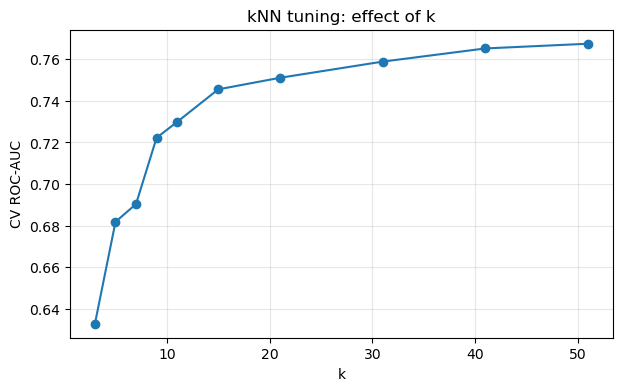

In [8]:
results = pd.DataFrame(knn_cv.cv_results_)
plot_data = results[results['param_weights'] == 'distance'].copy()
plot_data = plot_data.groupby('param_n_neighbors')['mean_test_score'].max()

plt.figure(figsize=(7, 4))
plt.plot(plot_data.index, plot_data.values, marker='o')
plt.xlabel('k')
plt.ylabel('CV ROC-AUC')
plt.title('kNN tuning: effect of k')
plt.grid(True, alpha=0.3)
plt.show()

## Final Evaluation and the Imbalance Effect

The final comparison uses the same tuned procedure twice:

1. train on the original imbalanced training set
2. train on a 50/50 down-sampled training set

The test set is not changed.

In [9]:
def evaluate(model, X_te, y_te, model_name, resample):
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)

    roc = roc_auc_score(y_te, proba)
    f1 = f1_score(y_te, pred)
    acc = accuracy_score(y_te, pred)

    print('--- %s (resample=%s) ---' % (model_name, resample))
    print('ROC-AUC : %.3f' % roc)
    print('F1      : %.3f' % f1)
    print('Accuracy: %.3f' % acc)
    print('Confusion matrix [rows = true 0/1, cols = predicted 0/1]:')
    print(confusion_matrix(y_te, pred))
    print(classification_report(y_te, pred, zero_division=0))

    return {'model': model_name, 'resample': resample,
            'roc_auc': roc, 'f1': f1, 'accuracy': acc}


def fit_knn(X_tr, y_tr):
    gs = GridSearchCV(KNeighborsClassifier(), param_grid,
                      scoring='roc_auc', cv=5, n_jobs=-1, refit=True)
    gs.fit(X_tr, y_tr)
    print('best parameters:', gs.best_params_)
    return gs.best_estimator_

### Run 1 — no resampling

In [10]:
knn_none = fit_knn(X_train_scaled, y_train)
row_none = evaluate(knn_none, X_test_scaled, y_test, 'knn', 'none')

best parameters: {'metric': 'euclidean', 'n_neighbors': 51, 'weights': 'distance'}
--- knn (resample=none) ---
ROC-AUC : 0.773
F1      : 0.317
Accuracy: 0.787
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[2525  200]
 [ 527  169]]
              precision    recall  f1-score   support

           0       0.83      0.93      0.87      2725
           1       0.46      0.24      0.32       696

    accuracy                           0.79      3421
   macro avg       0.64      0.58      0.60      3421
weighted avg       0.75      0.79      0.76      3421



### Run 2 — 50/50 down-sampling

In [11]:
train = X_train_enc.copy()
train['Hit'] = y_train.values

hits = train[train['Hit'] == 1]
flops = train[train['Hit'] == 0]

flops_down = flops.sample(n=len(hits), random_state=0)
train_bal = pd.concat([hits, flops_down]).sample(frac=1, random_state=0)

X_train_bal = train_bal.drop(columns='Hit')
y_train_bal = train_bal['Hit']

scaler_bal = StandardScaler()
X_train_bal_scaled = scaler_bal.fit_transform(X_train_bal)
X_test_bal_scaled = scaler_bal.transform(X_test_enc)

print('Balanced training set size:', len(y_train_bal))
print('Hit  (1):', len(y_train_bal[y_train_bal == 1]))
print('Flop (0):', len(y_train_bal[y_train_bal == 0]))

Balanced training set size: 5568
Hit  (1): 2784
Flop (0): 2784


In [12]:
knn_down = fit_knn(X_train_bal_scaled, y_train_bal)
row_down = evaluate(knn_down, X_test_bal_scaled, y_test, 'knn', 'downsample')

best parameters: {'metric': 'manhattan', 'n_neighbors': 51, 'weights': 'distance'}
--- knn (resample=downsample) ---
ROC-AUC : 0.778
F1      : 0.498
Accuracy: 0.667
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[1717 1008]
 [ 131  565]]
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      2725
           1       0.36      0.81      0.50       696

    accuracy                           0.67      3421
   macro avg       0.64      0.72      0.62      3421
weighted avg       0.81      0.67      0.70      3421



## Saving the Results

The two runs are saved with the same columns as the other Phase C model notebooks.

In [13]:
os.makedirs('results', exist_ok=True)

results = pd.DataFrame([row_none, row_down])
results = results[['model', 'resample', 'roc_auc', 'f1', 'accuracy']]

out_path = 'results/knn.csv'
results.to_csv(out_path, index=False)
print('Saved', out_path)
results

Saved results/knn.csv


,model,resample,roc_auc,f1,accuracy
0,knn,none,0.773302,0.317371,0.787489
1,knn,downsample,0.778232,0.498017,0.667056


# Naive Bayes

### Overview

- [Setup and Data Loading](#Setup-and-Data-Loading)
- [Data Understanding](#Data-Understanding)
- [Encoding the Features](#Encoding-the-Features)
- [The Majority Baseline](#The-Majority-Baseline)
- [A First Naive Bayes Model](#A-First-Naive-Bayes-Model)
- [Tuning Naive Bayes](#Tuning-Naive-Bayes)
- [Final Evaluation and the Imbalance Effect](#Final-Evaluation-and-the-Imbalance-Effect)
- [Saving the Results](#Saving-the-Results)

In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

## Setup and Data Loading

The train/test split and the leakage-safe `publisher_tier` are already created in Phase B.

In [2]:
SCOPE = "scope_2000_2018"
DATA_DIR = "data/processed/" + SCOPE

X_train = pd.read_csv(DATA_DIR + "/X_train.csv")
X_test  = pd.read_csv(DATA_DIR + "/X_test.csv")
y_train = pd.read_csv(DATA_DIR + "/y_train.csv")["Hit"]
y_test  = pd.read_csv(DATA_DIR + "/y_test.csv")["Hit"]

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
X_train.head()

X_train shape: (13681, 3)
X_test shape:  (3421, 3)


,genre,platform_family,publisher_tier
0,Shooter,PC,2
1,Sports,Xbox,2
2,Strategy,Nintendo,2
3,Action,PlayStation,0
4,Fighting,Xbox,0


## Data Understanding

The model only gets the three pre-release features from Phase B.

For Naive Bayes the class prior is important, so I check the class balance first.

In [3]:
print('Hit  (1):', len(y_train[y_train == 1]) / len(y_train))
print('Flop (0):', len(y_train[y_train == 0]) / len(y_train))

print()
print('Training labels:')
print(y_train.value_counts().sort_index())

Hit  (1): 0.2034938966449821
Flop (0): 0.7965061033550179

Training labels:
Hit
0    10897
1     2784
Name: count, dtype: int64


## Encoding the Features

`CategoricalNB` cannot directly use strings. Like in the Naive Bayes lecture notebook, I use `OrdinalEncoder` to convert categories to integer IDs.

For this model the numbers are only category IDs. They are not distances.

In [4]:
X_train_cat = X_train.astype(str)
X_test_cat = X_test.astype(str)

for col in X_train_cat.columns:
    unseen = sorted(set(X_test_cat[col]) - set(X_train_cat[col]))
    print(col, 'unseen test categories:', unseen)

enc = OrdinalEncoder()
X_train_enc = enc.fit_transform(X_train_cat)
X_test_enc = enc.transform(X_test_cat)

print('Encoded training shape:', X_train_enc.shape)
X_train_enc[:5]

genre unseen test categories: []
platform_family unseen test categories: []
publisher_tier unseen test categories: []
Encoded training shape: (13681, 3)


array([[10.,  2.,  2.],
       [12.,  4.,  2.],
       [13.,  0.,  2.],
       [ 0.,  3.,  0.],
       [ 3.,  4.,  0.]])

## The Majority Baseline

A simple baseline always predicts the majority class, which is `Flop`.

In [5]:
baseline_pred = np.zeros(len(y_test), dtype=int)

print('Baseline accuracy:', accuracy_score(y_test, baseline_pred))
print('Baseline F1      :', f1_score(y_test, baseline_pred, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, baseline_pred))

Baseline accuracy: 0.7965507161648641
Baseline F1      : 0.0
Confusion matrix:
[[2725    0]
 [ 696    0]]


## A First Naive Bayes Model

First I train a basic categorical Naive Bayes model with the default Laplace smoothing.

In [6]:
nb_first = CategoricalNB()
nb_first.fit(X_train_enc, y_train)

pred = nb_first.predict(X_test_enc)
proba = nb_first.predict_proba(X_test_enc)[:, 1]

print('Test accuracy:', accuracy_score(y_test, pred))
print('Test F1      :', f1_score(y_test, pred))
print('Test ROC-AUC :', roc_auc_score(y_test, proba))
print('Confusion matrix:')
print(confusion_matrix(y_test, pred))

Test accuracy: 0.797427652733119
Test F1      : 0.2376237623762376
Test ROC-AUC : 0.7744503321733629
Confusion matrix:
[[2620  105]
 [ 588  108]]


## Tuning Naive Bayes

The lecture explains Laplace smoothing. In scikit-learn this is controlled by `alpha`, so I try a few values.

In [7]:
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]}

nb_model = CategoricalNB()
nb_cv = GridSearchCV(nb_model, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
nb_cv.fit(X_train_enc, y_train)

print('Best CV ROC-AUC:', nb_cv.best_score_)
print('Best parameters:', nb_cv.best_params_)

Best CV ROC-AUC: 0.7683378870691064
Best parameters: {'alpha': 0.5}


## Final Evaluation and the Imbalance Effect

The final comparison uses the same tuned procedure twice:

1. train on the original imbalanced training set
2. train on a 50/50 down-sampled training set

The test set is not changed.

In [8]:
def evaluate(model, X_te, y_te, model_name, resample):
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)

    roc = roc_auc_score(y_te, proba)
    f1 = f1_score(y_te, pred)
    acc = accuracy_score(y_te, pred)

    print('--- %s (resample=%s) ---' % (model_name, resample))
    print('ROC-AUC : %.3f' % roc)
    print('F1      : %.3f' % f1)
    print('Accuracy: %.3f' % acc)
    print('Confusion matrix [rows = true 0/1, cols = predicted 0/1]:')
    print(confusion_matrix(y_te, pred))
    print(classification_report(y_te, pred, zero_division=0))

    return {'model': model_name, 'resample': resample,
            'roc_auc': roc, 'f1': f1, 'accuracy': acc}


def fit_nb(X_tr, y_tr):
    gs = GridSearchCV(CategoricalNB(), param_grid,
                      scoring='roc_auc', cv=5, n_jobs=-1, refit=True)
    gs.fit(X_tr, y_tr)
    print('best parameters:', gs.best_params_)
    return gs.best_estimator_

### Run 1 — no resampling

In [9]:
nb_none = fit_nb(X_train_enc, y_train)
row_none = evaluate(nb_none, X_test_enc, y_test, 'naive_bayes', 'none')

best parameters: {'alpha': 0.5}
--- naive_bayes (resample=none) ---
ROC-AUC : 0.774
F1      : 0.238
Accuracy: 0.797
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[2620  105]
 [ 588  108]]
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      2725
           1       0.51      0.16      0.24       696

    accuracy                           0.80      3421
   macro avg       0.66      0.56      0.56      3421
weighted avg       0.75      0.80      0.75      3421



### Run 2 — 50/50 down-sampling

In [10]:
train = pd.DataFrame(X_train_enc)
train['Hit'] = y_train.values

hits = train[train['Hit'] == 1]
flops = train[train['Hit'] == 0]

flops_down = flops.sample(n=len(hits), random_state=0)
train_bal = pd.concat([hits, flops_down]).sample(frac=1, random_state=0)

X_train_bal = train_bal.drop(columns='Hit')
y_train_bal = train_bal['Hit']

print('Balanced training set size:', len(y_train_bal))
print('Hit  (1):', len(y_train_bal[y_train_bal == 1]))
print('Flop (0):', len(y_train_bal[y_train_bal == 0]))

Balanced training set size: 5568
Hit  (1): 2784
Flop (0): 2784


In [11]:
nb_down = fit_nb(X_train_bal, y_train_bal)
row_down = evaluate(nb_down, X_test_enc, y_test, 'naive_bayes', 'downsample')

best parameters: {'alpha': 2.0}
--- naive_bayes (resample=downsample) ---
ROC-AUC : 0.775
F1      : 0.495
Accuracy: 0.665
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[1714 1011]
 [ 134  562]]
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      2725
           1       0.36      0.81      0.50       696

    accuracy                           0.67      3421
   macro avg       0.64      0.72      0.62      3421
weighted avg       0.81      0.67      0.70      3421



## Saving the Results

The two runs are saved with the same columns as the other Phase C model notebooks.

In [12]:
os.makedirs('results', exist_ok=True)

results = pd.DataFrame([row_none, row_down])
results = results[['model', 'resample', 'roc_auc', 'f1', 'accuracy']]

out_path = 'results/naive_bayes.csv'
results.to_csv(out_path, index=False)
print('Saved', out_path)
results

Saved results/naive_bayes.csv


,model,resample,roc_auc,f1,accuracy
0,naive_bayes,none,0.774490,0.237624,0.797428
1,naive_bayes,downsample,0.774917,0.495372,0.665303


*End of **Nikoloz Katsitadze**'s contribution (kNN & Naive Bayes).*

---

---

# Rodrigo Villarreal-Molina — Decision Tree & Random Forest

> The two sections below were built by **Rodrigo Villarreal-Molina**.

# Decision Tree

### Overview
- [Setup and Data Loading](#Setup-and-Data-Loading)
- [Data Understanding](#Data-Understanding)
- [Encoding the Features](#Encoding-the-Features)
- [The Majority Baseline](#The-Majority-Baseline)
- [A First Decision Tree (full tree)](#A-First-Decision-Tree-(full-tree))
- [Pre-Pruning with GridSearchCV](#Pre-Pruning-with-GridSearchCV)
- [Pre-Pruning with Minimum Impurity Decrease](#Pre-Pruning-with-Minimum-Impurity-Decrease)
- [Post-Pruning with Cost Complexity Pruning](#Post-Pruning-with-Cost-Complexity-Pruning)
- [Final Evaluation and the Imbalance Effect](#Final-Evaluation-and-the-Imbalance-Effect)
- [Saving the Results](#Saving-the-Results)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree # required for plot
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix # evaluation metrics

## Setup and Data Loading

The train/test split was produced in the preprocessing phase and stored in `data/processed/`.

Two scopes of the data are available. The primary one is `scope_2000_2018`; the `SCOPE` variable is used for ease of comparison between the two. The target is stored as a one-column CSV (column `Hit`), selected here as a plain `Series`:

In [2]:
SCOPE = "scope_2000_2018"
DATA_DIR = "data/processed/" + SCOPE

X_train = pd.read_csv(DATA_DIR + "/X_train.csv")
X_test  = pd.read_csv(DATA_DIR + "/X_test.csv")
y_train = pd.read_csv(DATA_DIR + "/y_train.csv")["Hit"]
y_test  = pd.read_csv(DATA_DIR + "/y_test.csv")["Hit"]

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
X_train.head()

X_train shape: (13681, 3)
X_test shape:  (3421, 3)


,genre,platform_family,publisher_tier
0,Shooter,PC,2
1,Sports,Xbox,2
2,Strategy,Nintendo,2
3,Action,PlayStation,0
4,Fighting,Xbox,0


## Data Understanding

The three input features are:

| Feature | Type | Meaning |
|---|---|---|
| `genre` | nominal (15 values) | e.g. Action, Shooter, Sports |
| `platform_family` | nominal (5 values) | Nintendo, PC, PlayStation, Xbox, Other |
| `publisher_tier` | ordinal (`0 < 1 < 2`) | the publisher's past million-seller count |

The class balance of the target is checked first. The classes are clearly not balanced:

In [3]:
print('Hit  (1):', len(y_train[y_train==1]) / len(y_train))
print('Flop (0):', len(y_train[y_train==0]) / len(y_train))

Hit  (1): 0.2034938966449821
Flop (0): 0.7965061033550179


Almost 80% of the games are Flops: model that always predicts "Flop" scores ~0.80. The evaluation therefore reports **ROC-AUC**, the **F1**, and the **confusion matrix**.

A check for missing values (this was handled in preprocessing):

In [4]:
X_train.isna().sum()

genre              0
platform_family    0
publisher_tier     0
dtype: int64

## Encoding the Features

The data needs to be converted to numerical. `genre` and `platform_family` are nominal, so instead of single integer they are **one-hot encoded** instead: each category becomes its own 0/1 column.

`publisher_tier` is ordinal so it is kept as a single numeric column (0<1<2).

Train and test are encoded identically and column-aligned, so both share exactly the same feature set:

In [5]:
cat_cols = ['genre', 'platform_family'] # nominal -> OHE

X_train_enc = pd.get_dummies(X_train, columns=cat_cols)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols)

# # fill missing categories to ensure test has same columns as train
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print('Number of features after one-hot encoding:', X_train_enc.shape[1])
X_train_enc.head()

Number of features after one-hot encoding: 21


,publisher_tier,genre_Action,genre_Action-Adventure,genre_Adventure,genre_Fighting,genre_Misc,genre_Music,genre_Platform,genre_Puzzle,genre_Racing,...,genre_Shooter,genre_Simulation,genre_Sports,genre_Strategy,genre_Visual Novel,platform_family_Nintendo,platform_family_Other,platform_family_PC,platform_family_PlayStation,platform_family_Xbox
0,2,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,2,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,2,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
3,0,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## The Majority Baseline

Because of the 80/20 imbalance, a majority class classifier already reaches ~0.80 accuracy, so accuracy alone is not a sufficient metric. Its metrics are computed explicitly as a reference point:

In [6]:
# always predict flop
baseline_pred = np.zeros(len(y_test), dtype=int)

print('Majority baseline accuracy:', accuracy_score(y_test, baseline_pred))
print('Majority baseline F1      :', f1_score(y_test, baseline_pred, zero_division=0))
print('Majority baseline ROC-AUC : 0.5 (a constant prediction cannot rank, so AUC = 0.5 by definition)')

Majority baseline accuracy: 0.7965507161648641
Majority baseline F1      : 0.0
Majority baseline ROC-AUC : 0.5 (a constant prediction cannot rank, so AUC = 0.5 by definition)


The numbers to beat are roughly accuracy 0.80, F1 0.0, ROC-AUC 0.5. A useful model has to raise F1 and ROC-AUC, even if accuracy barely moves.

## A First Decision Tree (full tree)

A tree is grown with no stopping criteria, so it can go as deep as it wants. Comparing train and test accuracy shows whether it overfits.

In [7]:
clf = DecisionTreeClassifier(random_state=0)
clf = clf.fit(X_train_enc, y_train)

y_pred = clf.predict(X_test_enc)

print('tree depth      :', clf.tree_.max_depth)
print('train accuracy  :', accuracy_score(y_train, clf.predict(X_train_enc)))
print('test accuracy   :', accuracy_score(y_test, y_pred))
print('test f1         :', f1_score(y_test, y_pred))

tree depth      : 19
train accuracy  : 0.8041809809224472
test accuracy   : 0.7985969014907922
test f1         : 0.20530565167243367


Train and test accuracy are almost the same (~0.80), so this tree hardly overfits. With only 3 features there are at most `15 x 5 x 3 = 225` distinct feature combinations but ~13,700 training games, so many games look identical to the tree and it can only predict the majority class inside each combination. That caps train accuracy near the base rate, unlike continuous-feature data where a full tree memorises everything and reaches ~100% train accuracy. The extra depth only adds noisy probability estimates, which the pruning below trims.

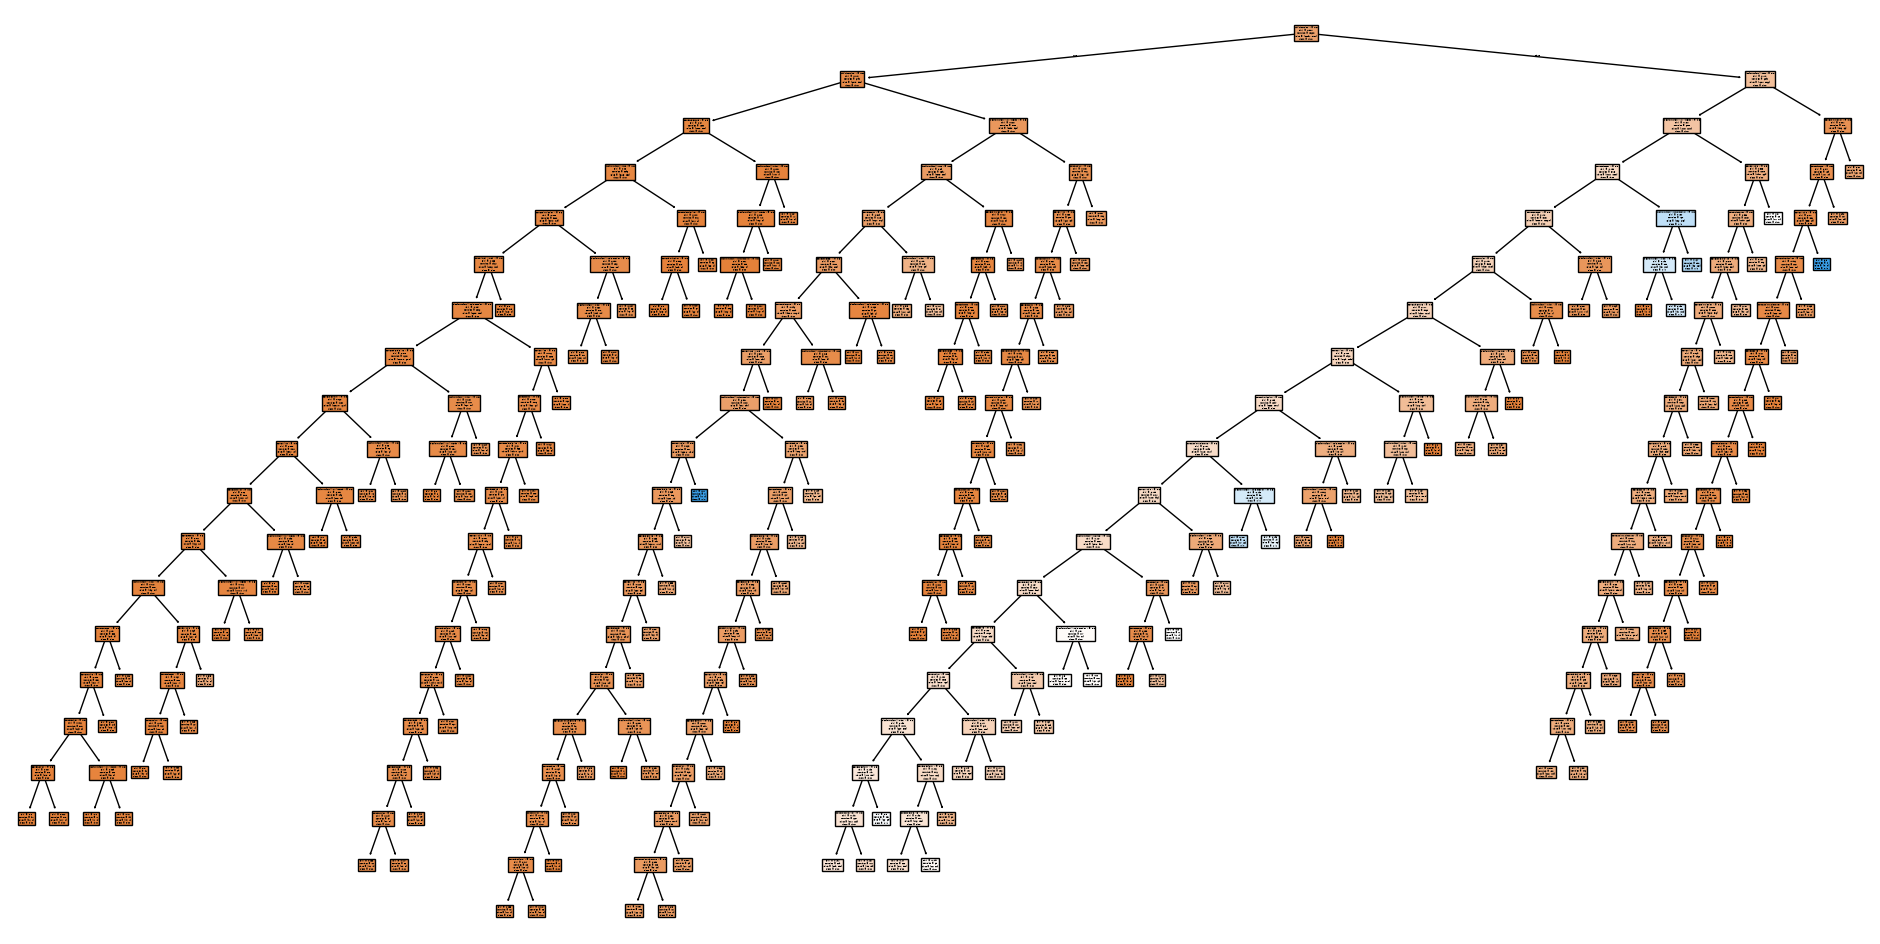

In [8]:
fig = plt.figure(figsize=(24,12))
text = tree.plot_tree(clf,
                   feature_names=X_train_enc.columns.to_list(),
                   class_names=['Flop','Hit'],
                   filled=True)
plt.show()

## Pre-Pruning with GridSearchCV

Instead of guessing `max_depth` and `criterion`, they are tuned with 10-fold cross-validation, scored on ROC-AUC since accuracy is misleading on imbalanced data.

In [9]:
cls = DecisionTreeClassifier(random_state=0)

params = {'max_depth':np.arange(3,15),
          'criterion':['gini','entropy']}
gs = GridSearchCV(cls, params, scoring='roc_auc', cv=10, verbose=1, n_jobs=-1)
gs.fit(X_train_enc, y_train)

Fitting 10 folds for each of 24 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': array([ 3, 4..., 12, 13, 14])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_dig

In [10]:
params_optimal = gs.best_params_

print("Best CV ROC-AUC: %f" % gs.best_score_)
print("Optimal Hyperparameter Values: ", params_optimal)

Best CV ROC-AUC: 0.773661
Optimal Hyperparameter Values:  {'criterion': 'gini', 'max_depth': np.int64(14)}


The best estimator, refit on the full training data by `GridSearchCV`, on the test set:

In [11]:
tree_best = gs.best_estimator_
pred = tree_best.predict(X_test_enc)

print('Test accuracy:', accuracy_score(y_test, pred))
print('Test f1      :', f1_score(y_test, pred))
print('Test ROC-AUC :', roc_auc_score(y_test, tree_best.predict_proba(X_test_enc)[:,1]))

Test accuracy: 0.8029815843320667
Test f1      : 0.18795180722891566
Test ROC-AUC : 0.7836235895813561


The pruned tree (max_depth 14) lands where the full tree did: ROC-AUC ~0.78, accuracy ~0.80, F1 even slightly lower. Pruning changes almost nothing here, which matches the earlier point that there was little to overfit. The tree is plotted below to read the splits:

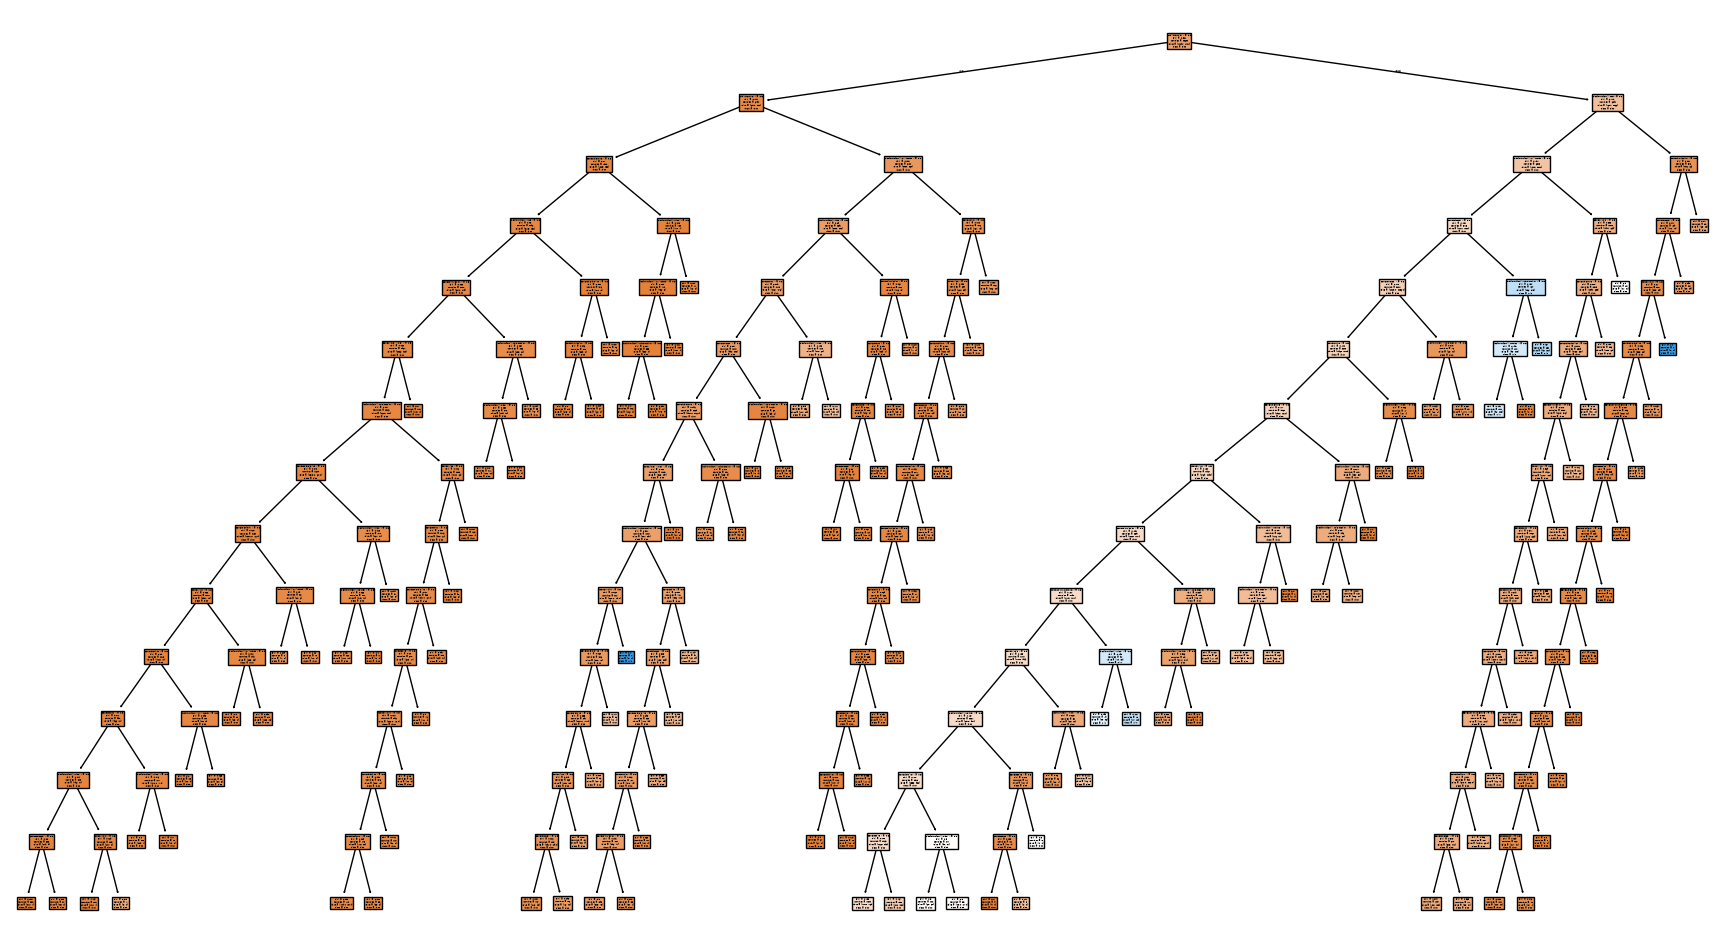

In [12]:
fig = plt.figure(figsize=(22,12))
text = tree.plot_tree(tree_best,
                   feature_names=X_train_enc.columns.to_list(),
                   class_names=['Flop','Hit'],
                   filled=True)
plt.show()

`publisher_tier` sits at or near the root, so the publisher's track record carries most of the signal. The `value` field in each node is the count of class 0 (Flop) vs class 1 (Hit).

## Pre-Pruning with Minimum Impurity Decrease

Another option: only split if impurity drops by at least `min_impurity_decrease`, again tuned with cross-validation. `gini` is kept since the criterion is about impurity.

In [13]:
cls = DecisionTreeClassifier(random_state=0, criterion='gini')

params = {'min_impurity_decrease':np.arange(0,.01,.0005)}
gs = GridSearchCV(cls, params, scoring='roc_auc', cv=10, verbose=1, n_jobs=-1)
gs.fit(X_train_enc, y_train)

print("Best CV ROC-AUC: %f" % gs.best_score_)
print("Optimal Hyperparameter Values: ", gs.best_params_)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best CV ROC-AUC: 0.774320
Optimal Hyperparameter Values:  {'min_impurity_decrease': np.float64(0.0)}


In [14]:
tree_mid = gs.best_estimator_
pred = tree_mid.predict(X_test_enc)

print('Test accuracy:', accuracy_score(y_test, pred))
print('Test f1      :', f1_score(y_test, pred))
print('Test ROC-AUC :', roc_auc_score(y_test, tree_mid.predict_proba(X_test_enc)[:,1]))

Test accuracy: 0.7985969014907922
Test f1      : 0.20530565167243367
Test ROC-AUC : 0.7828390277338395


The best `min_impurity_decrease` is 0.0, i.e. no pruning, giving the same scores as the full tree — again, nothing to prune.

## Post-Pruning with Cost Complexity Pruning

The other approach is to grow the full tree and cut it back afterwards with `ccp_alpha` (cost complexity pruning). This is used as the final decision-tree model. First the pruning path is computed: the `alpha` values at which the tree collapses node by node.

In [15]:
clf = DecisionTreeClassifier(random_state=0) # gini default
path = clf.cost_complexity_pruning_path(X_train_enc, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print('number of candidate alphas:', len(ccp_alphas))

number of candidate alphas: 125


As `alpha` grows the tree shrinks and total leaf impurity rises. In `R(T) + alpha*|T|`, `alpha = 0` is the full overfit tree and a large `alpha` a tiny underfit one; a good value sits in between.

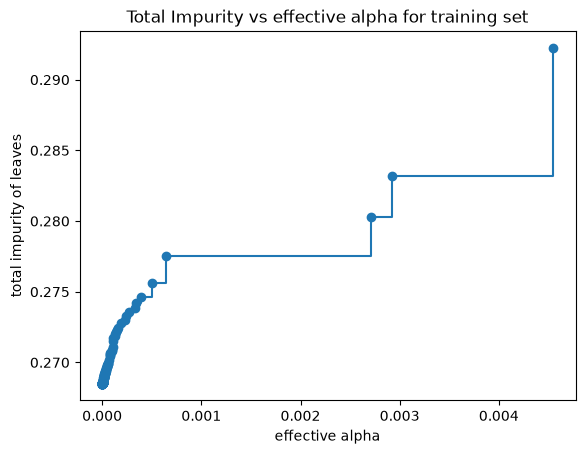

In [16]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Cross-validation picks the best `alpha` (the last one, a single-node tree, is dropped). The procedure is wrapped in `fit_pruned_tree` so it can be reused on the down-sampled data below.

In [17]:
def fit_pruned_tree(X_tr, y_tr):
    # full tree + its pruning path
    clf = DecisionTreeClassifier(random_state=0)
    path = clf.cost_complexity_pruning_path(X_tr, y_tr)
    ccp_alphas = path.ccp_alphas
    # cross-validate the alphas
    parameters = {'ccp_alpha': ccp_alphas[:-1].tolist()}
    gs = GridSearchCV(DecisionTreeClassifier(random_state=0), parameters,
                      scoring='roc_auc', cv=10, refit=True)
    gs.fit(X_tr, y_tr)
    print('best ccp_alpha:', gs.best_params_['ccp_alpha'])
    return gs.best_estimator_

tree_dt = fit_pruned_tree(X_train_enc, y_train)

best ccp_alpha: 1.558342864818596e-08


The final post-pruned tree on the full training data. The chosen `alpha` is tiny (~1e-8), so almost nothing is cut — consistent with the tree not overfitting much to begin with.

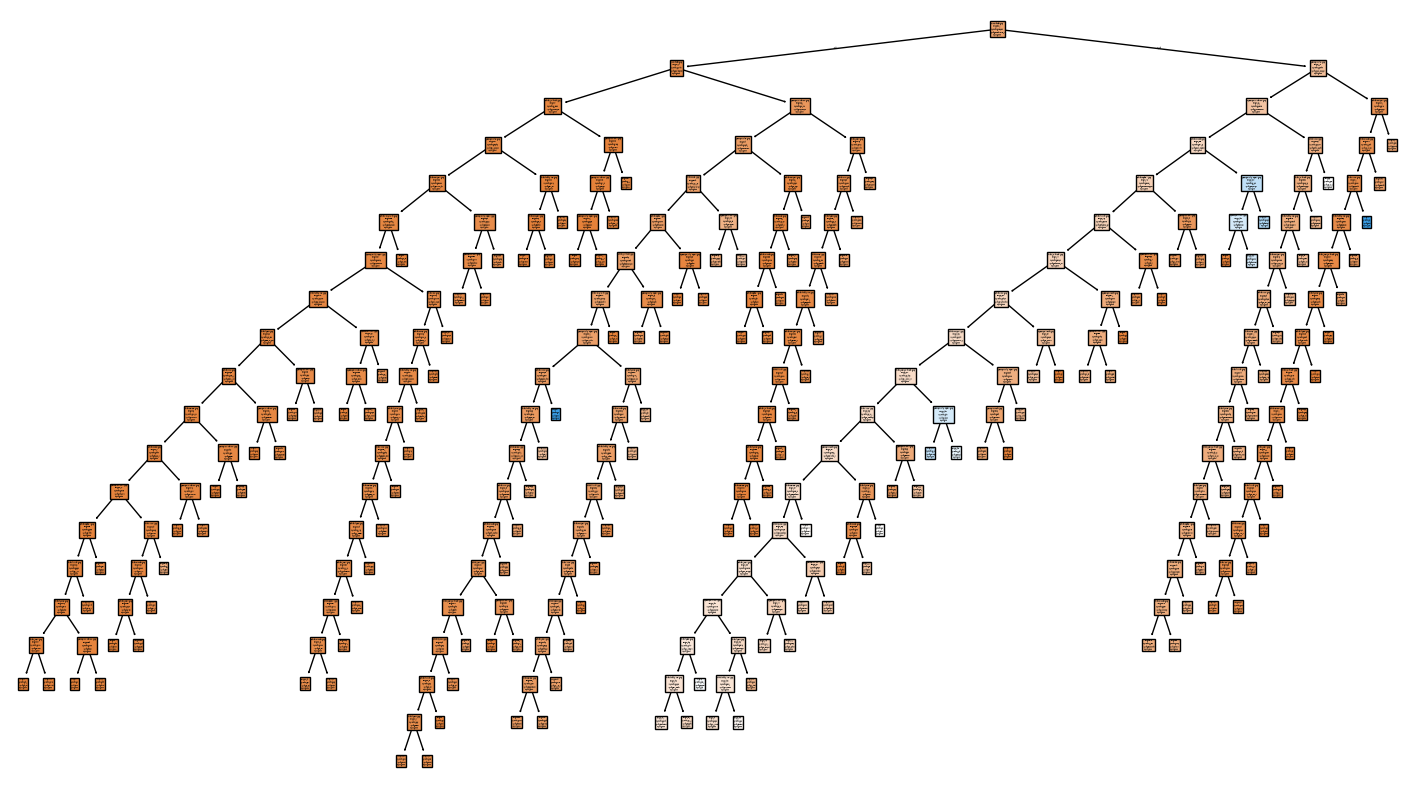

In [18]:
fig = plt.figure(figsize=(18,10))
text = tree.plot_tree(tree_dt,
                   feature_names=X_train_enc.columns.to_list(),
                   class_names=['Flop','Hit'],
                   filled=True)
plt.show()

## Final Evaluation and the Imbalance Effect

The model is run twice: on the data as-is (`resample = none`) and on a 50/50 down-sampled training set (`resample = downsample`), to see the effect of the imbalance. The `evaluate` helper prints the three metrics and the confusion matrix and returns one result row.

In [19]:
def evaluate(model, X_te, y_te, model_name, resample):
    proba = model.predict_proba(X_te)[:, 1] # prob of Hit
    pred  = model.predict(X_te)
    roc = roc_auc_score(y_te, proba)
    f1  = f1_score(y_te, pred)
    acc = accuracy_score(y_te, pred)
    print('--- %s (resample=%s) ---' % (model_name, resample))
    print('ROC-AUC : %.3f' % roc)
    print('F1      : %.3f' % f1)
    print('Accuracy: %.3f' % acc)
    print('Confusion matrix [rows = true 0/1, cols = predicted 0/1]:')
    print(confusion_matrix(y_te, pred))
    return {'model': model_name, 'resample': resample,
            'roc_auc': roc, 'f1': f1, 'accuracy': acc}

### Run 1 — no resampling

The post-pruned tree on the full training data:

In [20]:
row_none = evaluate(tree_dt, X_test_enc, y_test, 'decision_tree', 'none')

--- decision_tree (resample=none) ---
ROC-AUC : 0.783
F1      : 0.205
Accuracy: 0.799
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[2643   82]
 [ 607   89]]


### Run 2 — 50/50 down-sampling

The majority class (Flops) is down-sampled to the number of Hits. Only the training data is balanced; the test set is untouched.

In [21]:
# split by class
train = X_train_enc.copy()
train['Hit'] = y_train.values

hits  = train[train['Hit'] == 1]
flops = train[train['Hit'] == 0]

# downsample flops to the number of hits
flops_down = flops.sample(n=len(hits), random_state=0)

train_bal = pd.concat([hits, flops_down]).sample(frac=1, random_state=0) # shuffle
X_train_bal = train_bal.drop(columns='Hit')
y_train_bal = train_bal['Hit']

print('Balanced training set size:', len(y_train_bal))
print('Hit  (1):', len(y_train_bal[y_train_bal == 1]))
print('Flop (0):', len(y_train_bal[y_train_bal == 0]))

Balanced training set size: 5568
Hit  (1): 2784
Flop (0): 2784


The same procedure is trained on the balanced set and evaluated on the same test set:

In [22]:
tree_dt_bal = fit_pruned_tree(X_train_bal, y_train_bal)
row_down = evaluate(tree_dt_bal, X_test_enc, y_test, 'decision_tree', 'downsample')

best ccp_alpha: 8.732699151730097e-05
--- decision_tree (resample=downsample) ---
ROC-AUC : 0.780
F1      : 0.498
Accuracy: 0.659
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[1677 1048]
 [ 118  578]]


Down-sampling roughly doubles F1 (0.21 to 0.50) and trades away accuracy (0.80 to 0.66), while ROC-AUC barely moves (~0.78).

## Saving the Results

The two runs are saved with columns `model, resample, roc_auc, f1, accuracy`. The filename depends on `SCOPE`: the primary scope writes `results/decision_tree.csv`, any other scope writes a suffixed file like `results/decision_tree_scope_all.csv`, so running both scopes doesn't overwrite.

In [24]:
os.makedirs('results', exist_ok=True)

results = pd.DataFrame([row_none, row_down])
results = results[['model', 'resample', 'roc_auc', 'f1', 'accuracy']]

# for comparison only
if SCOPE == 'scope_2000_2018':
    out_path = 'results/decision_tree.csv'
else:
    out_path = 'results/decision_tree_' + SCOPE + '.csv'

results.to_csv(out_path, index=False)
print('Saved', out_path)
results

Saved results/decision_tree.csv


,model,resample,roc_auc,f1,accuracy
0,decision_tree,none,0.782798,0.205306,0.798597
1,decision_tree,downsample,0.779690,0.497847,0.659164


# Random Forest

### Overview
- [Setup and Data Loading](#Setup-and-Data-Loading)
- [Encoding the Features](#Encoding-the-Features)
- [The Majority Baseline](#The-Majority-Baseline)
- [From a Single Tree to a Forest (variance reduction)](#From-a-Single-Tree-to-a-Forest-(variance-reduction))
- [A Random Forest from a Parameter Guess](#A-Random-Forest-from-a-Parameter-Guess)
- [Tuning the Random Forest](#Tuning-the-Random-Forest)
- [Feature Importances](#Feature-Importances)
- [Final Evaluation and the Imbalance Effect](#Final-Evaluation-and-the-Imbalance-Effect)
- [Saving the Results](#Saving-the-Results)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix # evaluation metrics

## Setup and Data Loading

The train/test split was produced in the preprocessing phase and stored in `data/processed/`.
Two scopes of the data are available. The primary one is `scope_2000_2018`; the `SCOPE` variable is used for ease of comparison between the two.

In [2]:
SCOPE = "scope_2000_2018"
DATA_DIR = "data/processed/" + SCOPE

X_train = pd.read_csv(DATA_DIR + "/X_train.csv")
X_test  = pd.read_csv(DATA_DIR + "/X_test.csv")
y_train = pd.read_csv(DATA_DIR + "/y_train.csv")["Hit"]
y_test  = pd.read_csv(DATA_DIR + "/y_test.csv")["Hit"]

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print('Hit  (1):', len(y_train[y_train==1]) / len(y_train))
print('Flop (0):', len(y_train[y_train==0]) / len(y_train))

X_train shape: (13681, 3)
X_test shape:  (3421, 3)
Hit  (1): 0.2034938966449821
Flop (0): 0.7965061033550179


Same ~80/20 imbalance, so ROC-AUC, F1 and the confusion matrix are used, not accuracy alone.

## Encoding the Features

Same as the Decision Tree: `genre` and `platform_family` are one-hot encoded, `publisher_tier` stays numeric. Train and test are column-aligned.

In [3]:
cat_cols = ['genre', 'platform_family'] # nominal -> OHE

X_train_enc = pd.get_dummies(X_train, columns=cat_cols)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print('Number of features after one-hot encoding:', X_train_enc.shape[1])
X_train_enc.head()

Number of features after one-hot encoding: 21


,publisher_tier,genre_Action,genre_Action-Adventure,genre_Adventure,genre_Fighting,genre_Misc,genre_Music,genre_Platform,genre_Puzzle,genre_Racing,...,genre_Shooter,genre_Simulation,genre_Sports,genre_Strategy,genre_Visual Novel,platform_family_Nintendo,platform_family_Other,platform_family_PC,platform_family_PlayStation,platform_family_Xbox
0,2,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,2,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,2,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
3,0,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## The Majority Baseline

The reference to beat: always predict the majority class (Flop = `0`).

In [4]:
# always predict flop
baseline_pred = np.zeros(len(y_test), dtype=int)
print('Majority baseline accuracy:', accuracy_score(y_test, baseline_pred))
print('Majority baseline F1      :', f1_score(y_test, baseline_pred, zero_division=0))
print('Majority baseline ROC-AUC : 0.5 (constant prediction)')

Majority baseline accuracy: 0.7965507161648641
Majority baseline F1      : 0.0
Majority baseline ROC-AUC : 0.5 (constant prediction)


## From a Single Tree to a Forest

A single unpruned tree typically overfits.

In [16]:
# single unpruned tree
single_tree = DecisionTreeClassifier(criterion='entropy',
                                     max_depth=None,
                                     random_state=1)
single_tree = single_tree.fit(X_train_enc, y_train)
print('Single tree   train/test accuracy: %.3f / %.3f' % (
    accuracy_score(y_train, single_tree.predict(X_train_enc)),
    accuracy_score(y_test,  single_tree.predict(X_test_enc))))

# forest
forest = RandomForestClassifier(criterion='entropy',
                                n_estimators=100,
                                max_features='sqrt',
                                random_state=1,
                                n_jobs=-1)
forest = forest.fit(X_train_enc, y_train)
print('Random forest train/test accuracy: %.3f / %.3f' % (
    accuracy_score(y_train, forest.predict(X_train_enc)),
    accuracy_score(y_test,  forest.predict(X_test_enc))))

Single tree   train/test accuracy: 0.804 / 0.799
Random forest train/test accuracy: 0.804 / 0.799


No gap, same reason as the decision tree.

## A Random Forest from a Parameter Guess

A first forest with hand-picked parameters:

- `n_estimators` — number of trees (100–500),
- `max_features='sqrt'` — features considered per split,
- `max_samples` — bootstrap size (`None` = training-set size),
- `max_depth` — small trees are common in forests,
- `criterion` — gini or entropy.

Scored on the test set:

In [6]:
forest = RandomForestClassifier(criterion='gini',
                                n_estimators=100,
                                max_samples=None,  # bootstrap size = dataset size
                                max_features='sqrt',
                                max_depth=5,
                                random_state=1,
                                n_jobs=-1)
forest.fit(X_train_enc, y_train)

pred = forest.predict(X_test_enc)
print('Test accuracy:', accuracy_score(y_test, pred))
print('Test f1      :', f1_score(y_test, pred))
print('Test ROC-AUC :', roc_auc_score(y_test, forest.predict_proba(X_test_enc)[:,1]))

Test accuracy: 0.7965507161648641
Test f1      : 0.0
Test ROC-AUC : 0.7781538015395972


With `max_depth=5` the forest is so conservative it predicts Flop for every game (F1 = 0), even though its ROC-AUC is already ~0.78.

## Tuning the Random Forest



In [7]:
param_grid = {'n_estimators': np.array([100, 250]),
              'criterion': ['gini', 'entropy'],
              'max_depth': [3, 5, 7, None]}

forest = RandomForestClassifier(max_features='sqrt',
                                random_state=1,
                                n_jobs=-1)

forest_cv = GridSearchCV(forest, param_grid, scoring='roc_auc', cv=5,
                         verbose=1, n_jobs=-1, refit=True)
forest_cv.fit(X_train_enc, y_train)

print('Best CV ROC-AUC:', forest_cv.best_score_)
print('Best parameters:', forest_cv.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV ROC-AUC: 0.7743364169828476
Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'n_estimators': np.int64(250)}


In [8]:
best_forest = forest_cv.best_estimator_
pred = best_forest.predict(X_test_enc)

print('Test accuracy:', accuracy_score(y_test, pred))
print('Test f1      :', f1_score(y_test, pred))
print('Test ROC-AUC :', roc_auc_score(y_test, best_forest.predict_proba(X_test_enc)[:,1]))

Test accuracy: 0.7983045893013738
Test f1      : 0.08
Test ROC-AUC : 0.7826671412000421


The best parameters are kept as the final config and stored, so the same forest can be rebuilt on the down-sampled data below:

In [9]:
best_params = forest_cv.best_params_
print('final forest parameters:', best_params)

def fit_forest(X_tr, y_tr):
    # rebuild forest with tuned params
    rf = RandomForestClassifier(max_features='sqrt', random_state=1, n_jobs=-1,
                                **best_params)
    rf.fit(X_tr, y_tr)
    return rf

final forest parameters: {'criterion': 'entropy', 'max_depth': 7, 'n_estimators': np.int64(250)}


## Feature Importances



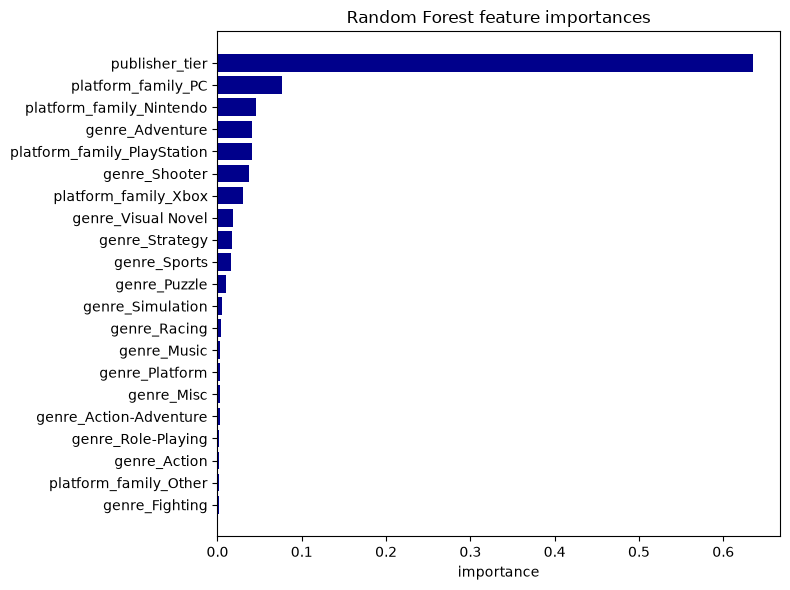

In [10]:
importances = pd.Series(best_forest.feature_importances_, index=X_train_enc.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importances.index, importances.values, color='darkblue')
plt.title('Random Forest feature importances')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

About 66% publisher tier. 

## Final Evaluation and the Imbalance Effect

The final forest is run twice: as-is (`resample = none`) and on a 50/50 down-sampled training set (`resample = downsample`). The `evaluate` helper prints the three metrics and the confusion matrix and returns one result row.

In [11]:
def evaluate(model, X_te, y_te, model_name, resample):
    proba = model.predict_proba(X_te)[:, 1] # prob of Hit
    pred  = model.predict(X_te)
    roc = roc_auc_score(y_te, proba)
    f1  = f1_score(y_te, pred)
    acc = accuracy_score(y_te, pred)
    print('--- %s (resample=%s) ---' % (model_name, resample))
    print('ROC-AUC : %.3f' % roc)
    print('F1      : %.3f' % f1)
    print('Accuracy: %.3f' % acc)
    print('Confusion matrix [rows = true 0/1, cols = predicted 0/1]:')
    print(confusion_matrix(y_te, pred))
    return {'model': model_name, 'resample': resample,
            'roc_auc': roc, 'f1': f1, 'accuracy': acc}

### Run 1 — no resampling

In [12]:
forest_none = fit_forest(X_train_enc, y_train)
row_none = evaluate(forest_none, X_test_enc, y_test, 'random_forest', 'none')

--- random_forest (resample=none) ---
ROC-AUC : 0.783
F1      : 0.080
Accuracy: 0.798
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[2701   24]
 [ 666   30]]


### Run 2 — 50/50 down-sampling

The majority class is down-sampled to the number of Hits; only the training data is balanced.

In [13]:
# split by class
train = X_train_enc.copy()
train['Hit'] = y_train.values

hits  = train[train['Hit'] == 1]
flops = train[train['Hit'] == 0]

# downsample flops to the number of hits
flops_down = flops.sample(n=len(hits), random_state=0)

train_bal = pd.concat([hits, flops_down]).sample(frac=1, random_state=0) # shuffle
X_train_bal = train_bal.drop(columns='Hit')
y_train_bal = train_bal['Hit']

print('Balanced training set size:', len(y_train_bal))
print('Hit  (1):', len(y_train_bal[y_train_bal == 1]))
print('Flop (0):', len(y_train_bal[y_train_bal == 0]))

Balanced training set size: 5568
Hit  (1): 2784
Flop (0): 2784


In [14]:
forest_bal = fit_forest(X_train_bal, y_train_bal)
row_down = evaluate(forest_bal, X_test_enc, y_test, 'random_forest', 'downsample')

--- random_forest (resample=downsample) ---
ROC-AUC : 0.781
F1      : 0.495
Accuracy: 0.640
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[1585 1140]
 [  92  604]]


Without resampling the forest is very conservative: it predicts Hit for only 54 games and finds just 30 of 696 real hits (F1 = 0.08, worse than the single tree). Down-sampling raises that to 604 of 696 hits found (F1 = 0.50), at the cost of accuracy, while ROC-AUC stays ~0.78. The imbalance effect is even stronger here than for the decision tree.

## Saving the Results

Saved with columns `model, resample, roc_auc, f1, accuracy`.

In [15]:
os.makedirs('results', exist_ok=True)

results = pd.DataFrame([row_none, row_down])
results = results[['model', 'resample', 'roc_auc', 'f1', 'accuracy']]

# for comparison only
if SCOPE == 'scope_2000_2018':
    out_path = 'results/random_forest.csv'
else:
    out_path = 'results/random_forest_' + SCOPE + '.csv'

results.to_csv(out_path, index=False)
print('Saved', out_path)
results

Saved results/random_forest.csv


,model,resample,roc_auc,f1,accuracy
0,random_forest,none,0.782667,0.080000,0.798305
1,random_forest,downsample,0.780825,0.495082,0.639871


*End of **Rodrigo Villarreal-Molina**'s contribution (Decision Tree & Random Forest).*

---

---

# Joshua Wüst — ANN (MLP) & Logistic Regression

> The two sections below were built by **Joshua Wüst**.

# Phase C — ANN (MLP)

CRISP-DM *Modeling*. Trains **only** on the leakage-safe outputs of Phase B
(`data/processed/<scope>/X_*`, `y_*`) — **no raw data, no re-preprocessing here.**

Shared rules (see README): one-hot for `genre`/`platform_family`, ordinal handling for
`publisher_tier`, run **twice** (no resampling vs. 50/50 train-downsample), evaluate on the
untouched test set with ROC-AUC + F1 + confusion matrix, beat the majority baseline, save to
`results/ann_mlp.csv`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42
SCOPE = "scope_2000_2018"   # primary scope (locked in Phase A/B)
DATA = f"data/processed/{SCOPE}"
MODEL_NAME = "ann_mlp"

## 1. Load processed data

Loaded **only** from `data/processed/<scope>/` — the leakage-safe train/test split from Phase B.
`meta_*` is for synthesis only and is not loaded as a feature here.

In [2]:
X_train = pd.read_csv(f"{DATA}/X_train.csv")
X_test  = pd.read_csv(f"{DATA}/X_test.csv")
y_train = pd.read_csv(f"{DATA}/y_train.csv")["Hit"]
y_test  = pd.read_csv(f"{DATA}/y_test.csv")["Hit"]

print("train:", X_train.shape, " test:", X_test.shape)
print("train Hit rate:", round(y_train.mean(), 3), " test Hit rate:", round(y_test.mean(), 3))
X_train.head()

train: (13681, 3)  test: (3421, 3)
train Hit rate: 0.203  test Hit rate: 0.203


,genre,platform_family,publisher_tier
0,Shooter,PC,2
1,Sports,Xbox,2
2,Strategy,Nintendo,2
3,Action,PlayStation,0
4,Fighting,Xbox,0


## 2. Encoding

- `genre`, `platform_family` — **nominal** → one-hot.
- `publisher_tier` — **ordinal** (0 < 1 < 2). Kept numeric and standardized — important for an
  MLP, since gradient-based training is sensitive to feature scale and one-hot columns are
  already on a 0/1 scale.

Fit on **train only**, applied to test — no leakage into the encoder.

In [3]:
NOMINAL = ["genre", "platform_family"]
ORDINAL = ["publisher_tier"]

preprocess = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), NOMINAL),
    ("scale", StandardScaler(), ORDINAL),
])

## 3. Majority baseline

Every run must beat this.

In [4]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)

print(f"Majority baseline — accuracy: {accuracy_score(y_test, base_pred):.3f}, "
      f"f1: {f1_score(y_test, base_pred, zero_division=0):.3f}, roc_auc: 0.500")

Majority baseline — accuracy: 0.797, f1: 0.000, roc_auc: 0.500


## 4. Helper functions

`downsample_50_50` balances the **training set only** (test set stays untouched, reflecting the
real ~80/20 split). `fit_and_eval` wraps a `GridSearchCV` fit + test-set evaluation.

In [5]:
def downsample_50_50(X, y, random_state=RANDOM_STATE):
    df = X.copy()
    df["Hit"] = y.values
    minority = df[df["Hit"] == 1]
    majority = df[df["Hit"] == 0].sample(n=len(minority), random_state=random_state)
    balanced = pd.concat([minority, majority]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns="Hit"), balanced["Hit"]


def fit_and_eval(pipeline, param_grid, Xtr, ytr, Xte, yte, label):
    grid = GridSearchCV(pipeline, param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
    grid.fit(Xtr, ytr)
    best = grid.best_estimator_

    proba = best.predict_proba(Xte)[:, 1]
    pred = best.predict(Xte)

    metrics = {
        "model": MODEL_NAME,
        "resample": label,
        "roc_auc": roc_auc_score(yte, proba),
        "f1": f1_score(yte, pred),
        "accuracy": accuracy_score(yte, pred),
    }

    print(f"--- {label} | best params: {grid.best_params_} ---")
    print(classification_report(yte, pred, target_names=["Flop", "Hit"]))
    ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=["Flop", "Hit"], cmap="Greens")
    plt.title(f"ANN (MLP) — {label}")
    plt.show()

    return metrics, best

## 5. Run 1 — no resampling

Trained directly on the imbalanced (~80/20) processed training set. `early_stopping=True` holds
out an internal validation slice of the *training* data to stop before overfitting — it does not
touch the test set.

--- none | best params: {'clf__activation': 'relu', 'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (32, 16)} ---
              precision    recall  f1-score   support

        Flop       0.81      0.98      0.89      2725
         Hit       0.60      0.10      0.17       696

    accuracy                           0.80      3421
   macro avg       0.71      0.54      0.53      3421
weighted avg       0.77      0.80      0.74      3421



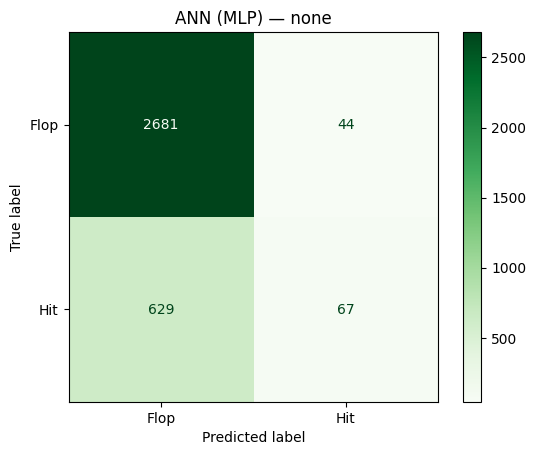

{'model': 'ann_mlp',
 'resample': 'none',
 'roc_auc': np.float64(0.7768614889802805),
 'f1': 0.16604708798017348,
 'accuracy': 0.803273896521485}

In [6]:
pipe = Pipeline([
    ("prep", preprocess),
    ("clf", MLPClassifier(max_iter=1000, early_stopping=True, random_state=RANDOM_STATE)),
])

param_grid = {
    "clf__hidden_layer_sizes": [(16,), (32,), (32, 16)],
    "clf__alpha": [0.0001, 0.001, 0.01],
    "clf__activation": ["relu"],
}

metrics_none, model_none = fit_and_eval(pipe, param_grid, X_train, y_train, X_test, y_test, "none")
metrics_none

## 6. Run 2 — 50/50 train-downsample

Same pipeline and grid, trained on a class-balanced subsample of the training set
(`downsample_50_50`). Evaluated on the same, untouched test set as Run 1.

balanced train shape: (5568, 3)  Hit rate: 0.5


--- downsample | best params: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (32, 16)} ---
              precision    recall  f1-score   support

        Flop       0.92      0.63      0.75      2725
         Hit       0.35      0.80      0.49       696

    accuracy                           0.66      3421
   macro avg       0.64      0.71      0.62      3421
weighted avg       0.81      0.66      0.69      3421



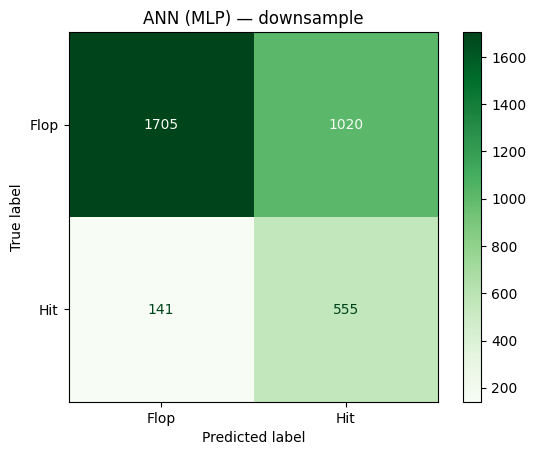

{'model': 'ann_mlp',
 'resample': 'downsample',
 'roc_auc': np.float64(0.7811375619529686),
 'f1': 0.48877146631439894,
 'accuracy': 0.6606255480853551}

In [7]:
X_train_bal, y_train_bal = downsample_50_50(X_train, y_train)
print("balanced train shape:", X_train_bal.shape, " Hit rate:", round(y_train_bal.mean(), 3))

metrics_bal, model_bal = fit_and_eval(pipe, param_grid, X_train_bal, y_train_bal, X_test, y_test, "downsample")
metrics_bal

## 7. Compare runs & save results

Both runs must clear the majority baseline (accuracy ≈ test Hit-rate complement, ROC-AUC = 0.5).
Results appended to `results/ann_mlp.csv` with columns `model, resample, roc_auc, f1, accuracy`
per the shared Phase C contract.

In [8]:
import os
os.makedirs("results", exist_ok=True)

results_df = pd.DataFrame([metrics_none, metrics_bal])[["model", "resample", "roc_auc", "f1", "accuracy"]]
display(results_df)

baseline_auc = 0.5
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f"Majority baseline — accuracy: {baseline_acc:.3f}, roc_auc: {baseline_auc:.3f}")
assert (results_df["roc_auc"] > baseline_auc).all(), "A run did not beat the majority baseline (AUC)!"

results_df.to_csv("results/ann_mlp.csv", index=False)
print("Saved -> results/ann_mlp.csv")

,model,resample,roc_auc,f1,accuracy
0,ann_mlp,none,0.776861,0.166047,0.803274
1,ann_mlp,downsample,0.781138,0.488771,0.660626


Majority baseline — accuracy: 0.797, roc_auc: 0.500
Saved -> results/ann_mlp.csv


## 8. Training curve sanity check

Plots the loss curve of the no-resample run's best estimator — confirms convergence (and that
`early_stopping` actually kicked in) rather than an arbitrary `max_iter` cutoff.

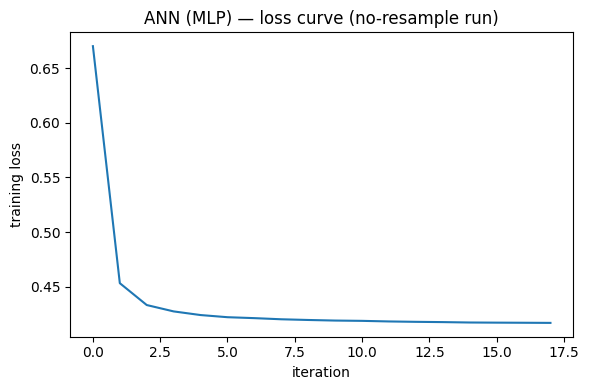

n_iter_: 18  stopped early: True


In [9]:
mlp = model_none.named_steps["clf"]
plt.figure(figsize=(6, 4))
plt.plot(mlp.loss_curve_)
plt.xlabel("iteration")
plt.ylabel("training loss")
plt.title("ANN (MLP) — loss curve (no-resample run)")
plt.tight_layout()
plt.show()
print("n_iter_:", mlp.n_iter_, " stopped early:", mlp.n_iter_ < mlp.max_iter)

In [10]:
# Final — re-save and show the results table
results_df.to_csv(f"results/ann_mlp.csv", index=False)
print(f"Saved -> results/ann_mlp.csv")
results_df

Saved -> results/ann_mlp.csv


,model,resample,roc_auc,f1,accuracy
0,ann_mlp,none,0.776861,0.166047,0.803274
1,ann_mlp,downsample,0.781138,0.488771,0.660626


# Phase C — Logistic Regression

CRISP-DM *Modeling*. Trains **only** on the leakage-safe outputs of Phase B
(`data/processed/<scope>/X_*`, `y_*`) — **no raw data, no re-preprocessing here.**

Shared rules (see README): one-hot for `genre`/`platform_family`, ordinal handling for
`publisher_tier`, run **twice** (no resampling vs. 50/50 train-downsample), evaluate on the
untouched test set with ROC-AUC + F1 + confusion matrix, beat the majority baseline, save to
`results/logistic_regression.csv`.

In [9]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42
SCOPE = "scope_2000_2018"   # primary scope (locked in Phase A/B)
DATA = f"data/processed/{SCOPE}"
MODEL_NAME = "logistic_regression"

## 1. Load processed data

Loaded **only** from `data/processed/<scope>/` — this is the leakage-safe train/test split
produced by Phase B. `meta_*` is for synthesis only and is not loaded as a feature here.

In [10]:
X_train = pd.read_csv(f"{DATA}/X_train.csv")
X_test  = pd.read_csv(f"{DATA}/X_test.csv")
y_train = pd.read_csv(f"{DATA}/y_train.csv")["Hit"]
y_test  = pd.read_csv(f"{DATA}/y_test.csv")["Hit"]

print("train:", X_train.shape, " test:", X_test.shape)
print("train Hit rate:", round(y_train.mean(), 3), " test Hit rate:", round(y_test.mean(), 3))
X_train.head()

train: (13681, 3)  test: (3421, 3)
train Hit rate: 0.203  test Hit rate: 0.203


,genre,platform_family,publisher_tier
0,Shooter,PC,2
1,Sports,Xbox,2
2,Strategy,Nintendo,2
3,Action,PlayStation,0
4,Fighting,Xbox,0


## 2. Encoding

- `genre`, `platform_family` — **nominal** → one-hot.
- `publisher_tier` — **ordinal** (0 < 1 < 2). Kept as a single numeric column and standardized
  (mean 0 / unit variance) so its scale doesn't dominate the one-hot columns inside the
  L2-regularized logistic loss.

Built as a `ColumnTransformer` inside a `Pipeline`, fit on **train only** (then applied to test) —
no leakage into the encoder either.

In [11]:
NOMINAL = ["genre", "platform_family"]
ORDINAL = ["publisher_tier"]

preprocess = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), NOMINAL),
    ("scale", StandardScaler(), ORDINAL),
])

## 3. Majority baseline

Every run must beat this.

In [12]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
base_proba = np.zeros(len(X_test))  # majority classifier -> no discrimination, AUC = 0.5

print(f"Majority baseline — accuracy: {accuracy_score(y_test, base_pred):.3f}, "
      f"f1: {f1_score(y_test, base_pred, zero_division=0):.3f}, roc_auc: 0.500")

Majority baseline — accuracy: 0.797, f1: 0.000, roc_auc: 0.500


## 4. Helper functions

`downsample_50_50` balances the **training set only** (test set stays untouched — it must reflect
the real ~80/20 class split). `fit_and_eval` wraps a `GridSearchCV` fit + test-set evaluation.

In [13]:
def downsample_50_50(X, y, random_state=RANDOM_STATE):
    df = X.copy()
    df["Hit"] = y.values
    minority = df[df["Hit"] == 1]
    majority = df[df["Hit"] == 0].sample(n=len(minority), random_state=random_state)
    balanced = pd.concat([minority, majority]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns="Hit"), balanced["Hit"]


def fit_and_eval(pipeline, param_grid, Xtr, ytr, Xte, yte, label):
    grid = GridSearchCV(pipeline, param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
    grid.fit(Xtr, ytr)
    best = grid.best_estimator_

    proba = best.predict_proba(Xte)[:, 1]
    pred = best.predict(Xte)

    metrics = {
        "model": MODEL_NAME,
        "resample": label,
        "roc_auc": roc_auc_score(yte, proba),
        "f1": f1_score(yte, pred),
        "accuracy": accuracy_score(yte, pred),
    }

    print(f"--- {label} | best params: {grid.best_params_} ---")
    print(classification_report(yte, pred, target_names=["Flop", "Hit"]))
    ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=["Flop", "Hit"], cmap="Blues")
    plt.title(f"Logistic Regression — {label}")
    plt.show()

    return metrics, best

## 5. Run 1 — no resampling

Trained directly on the (imbalanced, ~80/20) processed training set. `class_weight=None` here —
balancing is handled explicitly by the downsample run below, not implicitly via class weights, so
the two runs isolate the effect cleanly (per README Lec 5 note).

--- none | best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} ---
              precision    recall  f1-score   support

        Flop       0.81      0.98      0.89      2725
         Hit       0.60      0.09      0.16       696

    accuracy                           0.80      3421
   macro avg       0.71      0.54      0.52      3421
weighted avg       0.77      0.80      0.74      3421



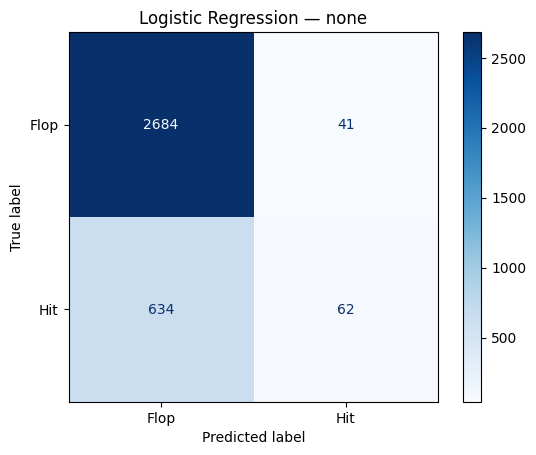

{'model': 'logistic_regression',
 'resample': 'none',
 'roc_auc': np.float64(0.7755132869345144),
 'f1': 0.15519399249061328,
 'accuracy': 0.8026892721426484}

In [14]:
pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

metrics_none, model_none = fit_and_eval(pipe, param_grid, X_train, y_train, X_test, y_test, "none")
metrics_none

## 6. Run 2 — 50/50 train-downsample

Same pipeline and grid, but trained on a class-balanced **subsample of the training set**
(`downsample_50_50`). Evaluated on the same, untouched test set as Run 1 — so the two rows are
directly comparable.

balanced train shape: (5568, 3)  Hit rate: 0.5
--- downsample | best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} ---
              precision    recall  f1-score   support

        Flop       0.92      0.65      0.76      2725
         Hit       0.36      0.77      0.49       696

    accuracy                           0.67      3421
   macro avg       0.64      0.71      0.62      3421
weighted avg       0.80      0.67      0.70      3421



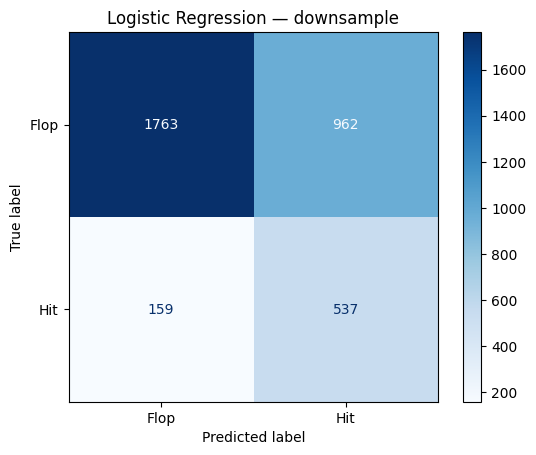

{'model': 'logistic_regression',
 'resample': 'downsample',
 'roc_auc': np.float64(0.7739589265000527),
 'f1': 0.48929384965831435,
 'accuracy': 0.6723180356620871}

In [15]:
X_train_bal, y_train_bal = downsample_50_50(X_train, y_train)
print("balanced train shape:", X_train_bal.shape, " Hit rate:", round(y_train_bal.mean(), 3))

metrics_bal, model_bal = fit_and_eval(pipe, param_grid, X_train_bal, y_train_bal, X_test, y_test, "downsample")
metrics_bal

## 7. Compare runs & save results

Both runs must clear the majority baseline (accuracy ≈ test Hit-rate complement, ROC-AUC = 0.5).
Results appended to `results/logistic_regression.csv` with columns
`model, resample, roc_auc, f1, accuracy` per the shared Phase C contract.

In [16]:
import os
os.makedirs("results", exist_ok=True)

results_df = pd.DataFrame([metrics_none, metrics_bal])[["model", "resample", "roc_auc", "f1", "accuracy"]]
display(results_df)

baseline_auc = 0.5
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f"Majority baseline — accuracy: {baseline_acc:.3f}, roc_auc: {baseline_auc:.3f}")
assert (results_df["roc_auc"] > baseline_auc).all(), "A run did not beat the majority baseline (AUC)!"

results_df.to_csv("results/logistic_regression.csv", index=False)
print("Saved -> results/logistic_regression.csv")

,model,resample,roc_auc,f1,accuracy
0,logistic_regression,none,0.775513,0.155194,0.802689
1,logistic_regression,downsample,0.773959,0.489294,0.672318


Majority baseline — accuracy: 0.797, roc_auc: 0.500
Saved -> results/logistic_regression.csv


## 8. Feature importance (coefficients)

Quick look at which one-hot levels / `publisher_tier` push the no-resample model toward "Hit" —
sanity check that `publisher_tier` dominates, consistent with the README's note on the dominant
feature.

,feature,coef
14,onehot__genre_Visual Novel,-2.764105
16,onehot__platform_family_Other,-1.735958
17,onehot__platform_family_PC,-1.187030
20,scale__publisher_tier,1.061874
10,onehot__genre_Shooter,0.659912
13,onehot__genre_Strategy,-0.626485
18,onehot__platform_family_PlayStation,0.553431
7,onehot__genre_Puzzle,-0.506979
1,onehot__genre_Action-Adventure,0.475451
19,onehot__platform_family_Xbox,0.472685


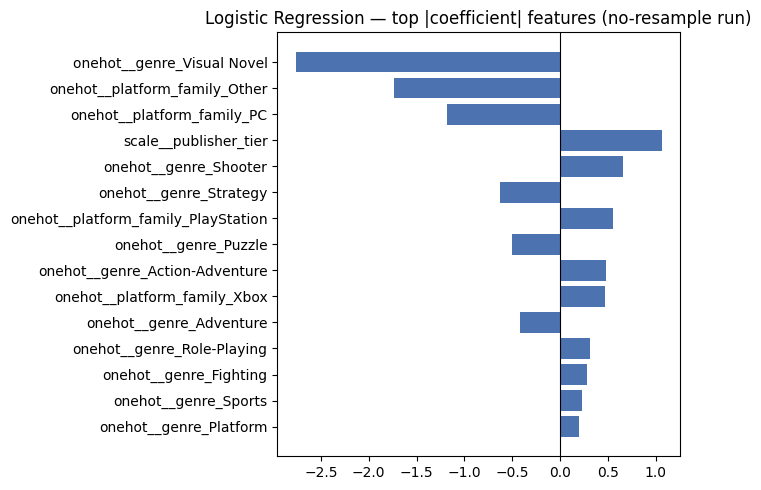

In [17]:
feature_names = model_none.named_steps["prep"].get_feature_names_out()
coefs = model_none.named_steps["clf"].coef_[0]

coef_df = (pd.DataFrame({"feature": feature_names, "coef": coefs})
           .sort_values("coef", key=abs, ascending=False)
           .head(15))
display(coef_df)

plt.figure(figsize=(7, 5))
plt.barh(coef_df["feature"][::-1], coef_df["coef"][::-1], color="#4C72B0")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — top |coefficient| features (no-resample run)")
plt.tight_layout()
plt.show()

In [18]:
# Final — re-save and show the results table
results_df.to_csv(f"results/logistic_regression.csv", index=False)
print(f"Saved -> results/logistic_regression.csv")
results_df

Saved -> results/logistic_regression.csv


,model,resample,roc_auc,f1,accuracy
0,logistic_regression,none,0.775513,0.155194,0.802689
1,logistic_regression,downsample,0.773959,0.489294,0.672318


*End of **Joshua Wüst**'s contribution (ANN (MLP) & Logistic Regression).*

---

## Synthesis — Model comparison & robustness

We collect the six models' results, then stress-test the conclusions on the **top two** (Random Forest &
ANN). For the robustness checks the two models are used **exactly as Rodrigo and Joshua tuned them**
(configs frozen), only the *input* changes per experiment.

,model,resample,roc_auc,f1,accuracy
0,kNN,none,0.773,0.317,0.787
1,kNN,50/50,0.778,0.498,0.667
2,Naive Bayes,none,0.774,0.238,0.797
3,Naive Bayes,50/50,0.775,0.495,0.665
4,Decision Tree,none,0.783,0.205,0.799
5,Decision Tree,50/50,0.780,0.498,0.659
6,Random Forest,none,0.783,0.080,0.798
7,Random Forest,50/50,0.781,0.495,0.640
8,ANN (MLP),none,0.777,0.166,0.803
9,ANN (MLP),50/50,0.781,0.489,0.661


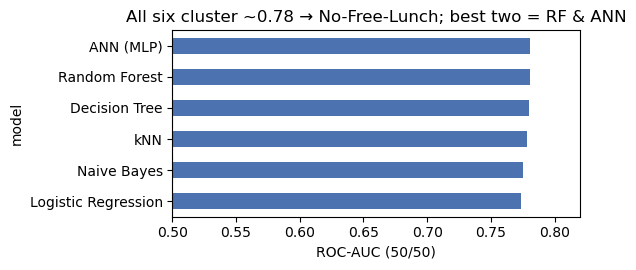

In [1]:
%matplotlib inline
import pandas as pd, matplotlib.pyplot as plt

# Metrics as reported by each author's own notebook (see their sections above)
comp = pd.DataFrame([
 ["kNN","none",0.773,0.317,0.787],["kNN","50/50",0.778,0.498,0.667],
 ["Naive Bayes","none",0.774,0.238,0.797],["Naive Bayes","50/50",0.775,0.495,0.665],
 ["Decision Tree","none",0.783,0.205,0.799],["Decision Tree","50/50",0.780,0.498,0.659],
 ["Random Forest","none",0.783,0.080,0.798],["Random Forest","50/50",0.781,0.495,0.640],
 ["ANN (MLP)","none",0.777,0.166,0.803],["ANN (MLP)","50/50",0.781,0.489,0.661],
 ["Logistic Regression","none",0.776,0.155,0.803],["Logistic Regression","50/50",0.774,0.489,0.672],
], columns=["model","resample","roc_auc","f1","accuracy"])
display(comp)

auc = comp[comp["resample"]=="50/50"].set_index("model")["roc_auc"].sort_values()
ax = auc.plot.barh(figsize=(6,2.8), color="#4C72B0", xlim=(0.5,0.82))
ax.axvline(0.5, ls="--", color="gray"); ax.set_xlabel("ROC-AUC (50/50)")
ax.set_title("All six cluster ~0.78 → No-Free-Lunch; best two = RF & ANN")
plt.tight_layout(); plt.show()

### Feature ablation (RF & ANN)
Drop one feature at a time (models frozen) → how much does each contribute? ROC-AUC on the test set.

In [2]:
import numpy as np, warnings; warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

FE = ["genre","platform_family","publisher_tier"]
P = "data/processed/scope_2000_2018/"
Xtr = pd.read_csv(P+"X_train.csv"); Xte = pd.read_csv(P+"X_test.csv")
ytr = pd.read_csv(P+"y_train.csv")["Hit"].values; yte = pd.read_csv(P+"y_test.csv")["Hit"].values

# Rodrigo's RF and Joshua's ANN — exact tuned configs, frozen; only the input changes.
def rf_auc(Xa,ya,Xb,yb,feats=FE):
    cat=[c for c in ["genre","platform_family"] if c in feats]
    A=pd.get_dummies(Xa[feats],columns=cat); B=pd.get_dummies(Xb[feats],columns=cat).reindex(columns=A.columns,fill_value=0)
    m=RandomForestClassifier(criterion="entropy",max_depth=7,n_estimators=250,max_features="sqrt",random_state=1,n_jobs=-1).fit(A,ya)
    return roc_auc_score(yb, m.predict_proba(B)[:,1])
def ann_auc(Xa,ya,Xb,yb,feats=FE):
    nom=[c for c in ["genre","platform_family"] if c in feats]; ordi=[c for c in ["publisher_tier"] if c in feats]
    t=[]
    if nom: t.append(("oh",OneHotEncoder(handle_unknown="ignore"),nom))
    if ordi: t.append(("sc",StandardScaler(),ordi))
    pipe=Pipeline([("prep",ColumnTransformer(t)),("clf",MLPClassifier(hidden_layer_sizes=(32,16),alpha=0.01,
                   activation="relu",max_iter=1000,early_stopping=True,random_state=42))]).fit(Xa[feats],ya)
    return roc_auc_score(yb, pipe.predict_proba(Xb[feats])[:,1])

variants={"full":FE,"− genre":["platform_family","publisher_tier"],"− platform":["genre","publisher_tier"],
          "− publisher_tier":["genre","platform_family"],"publisher_tier only":["publisher_tier"]}
rb=rf_auc(Xtr,ytr,Xte,yte); ab=ann_auc(Xtr,ytr,Xte,yte)
rows=[]
for k,v in variants.items():
    r=rf_auc(Xtr,ytr,Xte,yte,v); a=ann_auc(Xtr,ytr,Xte,yte,v)
    rows.append({"feature set":k,"RF AUC":round(r,3),"ΔRF":round(r-rb,3),"ANN AUC":round(a,3),"ΔANN":round(a-ab,3)})
display(pd.DataFrame(rows))

,feature set,RF AUC,ΔRF,ANN AUC,ΔANN
0,full,0.783,0.000,0.777,0.000
1,− genre,0.763,-0.019,0.746,-0.031
2,− platform,0.746,-0.036,0.604,-0.172
3,− publisher_tier,0.683,-0.100,0.604,-0.173
4,publisher_tier only,0.719,-0.064,0.719,-0.058


### Scope — is the 2000 cutoff justified?
Add pre-2000 games to **training** and score on the **same 2000–2018 test rows** (asserted no overlap →
no leakage). If older data helped, AUC would rise.

In [3]:
from sklearn.model_selection import train_test_split
raw = pd.read_csv("data/raw/Video Games Sales (1980-2024) - Raw.csv")
raw["year"]=pd.to_datetime(raw["release_date"],format="%d-%m-%Y",errors="coerce").dt.year
FAM={}
for x in ['PS','PS2','PS3','PS4','PS5','PSP','PSV','PSN']:FAM[x]='PlayStation'
for x in ['XB','X360','XOne','XS','XBL']:FAM[x]='Xbox'
for x in ['NS','Wii','WiiU','DS','DSi','DSiW','3DS','GB','GBC','GBA','SNES','NES','N64','GC','VB','VC','FDS','iQue']:FAM[x]='Nintendo'
for x in ['PC','OSX','Linux']:FAM[x]='PC'
raw["platform_family"]=raw["console"].map(FAM).fillna("Other")
raw["genre"]=raw["genre"].replace(["Education","Board Game","Sandbox","Party","MMO"],"Misc")
hit=lambda s:(s["total_sales"]>=s.groupby("year")["total_sales"].transform(lambda x:x.quantile(0.80))).astype(int)
def add_tier(tr,te):
    u=tr.drop_duplicates(["title","publisher"]).assign(ic=lambda x:(x["total_sales"]>=1.0).astype(int))
    cnt=u.groupby("publisher")["ic"].sum(); f=lambda n:0 if n<=0 else(1 if n<=4 else 2); tl={p:f(n) for p,n in cnt.items()}
    tr=tr.copy(); te=te.copy()
    tr["publisher_tier"]=tr["publisher"].map(tl).fillna(0).astype(int); te["publisher_tier"]=te["publisher"].map(tl).fillna(0).astype(int)
    return tr,te

s2=raw[(raw["year"].between(2000,2018))&raw["total_sales"].notna()].copy(); s2["Hit"]=hit(s2)
tr2,te2=train_test_split(s2,test_size=0.2,random_state=42,stratify=s2["Hit"])
pre=raw[(raw["year"]<2000)&raw["total_sales"].notna()].copy(); pre["Hit"]=hit(pre)
assert len(set(te2.index)&set(pd.concat([tr2,pre]).index))==0, "leak: test row in train"

def row(train,label):
    tr,te=add_tier(train,te2)
    return {"train scope":label,"n_train":len(train),
            "RF AUC":round(rf_auc(tr,tr["Hit"].values,te,te["Hit"].values),3),
            "ANN AUC":round(ann_auc(tr,tr["Hit"].values,te,te["Hit"].values),3)}
display(pd.DataFrame([row(tr2,"2000–2018"), row(pd.concat([tr2,pre]),"all ≤2018 (+pre-2000)")]))

,train scope,n_train,RF AUC,ANN AUC
0,2000–2018,13681,0.783,0.777
1,all ≤2018 (+pre-2000),15348,0.780,0.775


### Threshold robustness — top 20% vs 30%
Re-label the target at both cut-offs (same features, same models). Does the conclusion depend on the exact threshold?

In [4]:
mtr=pd.read_csv(P+"meta_train.csv"); mte=pd.read_csv(P+"meta_test.csv")
def lab(m,q):
    thr=pd.concat([mtr,mte]).groupby("year")["total_sales"].quantile(1-q)
    return (m["total_sales"]>=m["year"].map(thr)).astype(int).values
rows=[]
for q in [0.20,0.30]:
    ya,yb=lab(mtr,q),lab(mte,q)
    rows.append({"threshold":f"top {int(q*100)}%","test Hit%":f"{yb.mean():.0%}",
                 "RF AUC":round(rf_auc(Xtr,ya,Xte,yb),3),"ANN AUC":round(ann_auc(Xtr,ya,Xte,yb),3)})
display(pd.DataFrame(rows))

,threshold,test Hit%,RF AUC,ANN AUC
0,top 20%,20%,0.783,0.777
1,top 30%,30%,0.771,0.763


### Conclusions

- **No-Free-Lunch:** all six models cluster at ROC-AUC ~0.78; the best two are **Random Forest & ANN**.
- **`publisher_tier` is the dominant feature** in both (dropping it: −0.10 RF / −0.17 ANN); tier alone ≈ 0.72.
- **2000 cutoff is justified:** adding pre-2000 games does **not** help (Δ ≈ −0.003), on identical test rows.
- **Threshold-robust:** 20% vs 30% both ~0.77–0.78 → the exact cut-off is not critical.
- The **~0.78 ceiling** reflects drivers we cannot see before release (marketing, hype) — a finding, not a failure.